In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. تعريف الخصائص الثابتة للمكمن (Reservoir Properties)
P_b = 2500      # ضغط نقطة الفقاعة بالـ psi
B_ob = 1.32     # معامل حجم التكوين عند ضغط الفقاعة (bbl/STB)
c_o = 1.5e-5    # انضغاطية النفط (1/psi)

# 2. توليد نطاق من الضغوط من 500 إلى 5000 psi لمحاكاة هبوط الضغط
pressures = np.linspace(500, 5000, 100)

print("تم تعريف المتغيرات ونطاق الضغط بنجاح!")

تم تعريف المتغيرات ونطاق الضغط بنجاح!


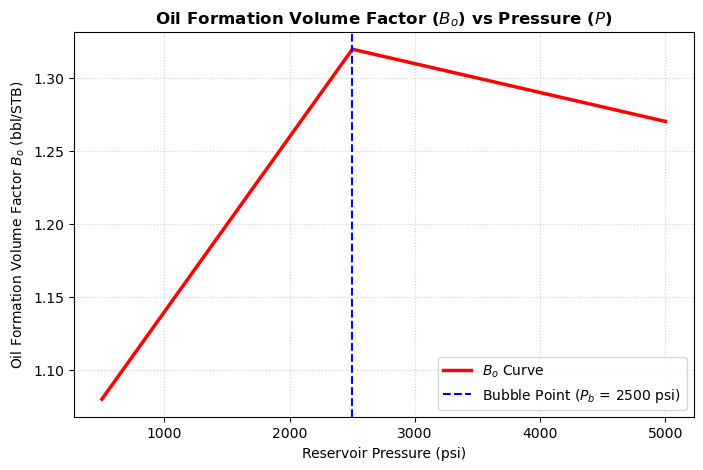

In [3]:
# 1. إنشاء قائمة فارغة لتخزين قيم Bo المحسوبة
Bo_results = []

# 2. المرور على كل قيمة ضغط وتطبيق المعادلات الفيزيائية
for P in pressures:
    if P >= P_b:
        # معادلة النفط فوق ضغط الفقاعة (Under-saturated Oil)
        Bo = B_ob * (1 - c_o * (P - P_b))
    else:
        # محاكاة هبوط الحجم تحت ضغط الفقاعة نتيجة خروج الغاز (Saturated Oil)
        # ينخفض الحجم تدريجياً كلما قل الضغط عن P_b
        Bo = B_ob - 0.00012 * (P_b - P)
    
    Bo_results.append(Bo)

# 3. تحويل النتائج إلى مصفوفة Numpy لسهولة التعامل معها
Bo_results = np.array(Bo_results)

# 4. رسم المنحنى البياني الهندسي (PVT Plot)
plt.figure(figsize=(8, 5))
plt.plot(pressures, Bo_results, color='red', linewidth=2.5, label='$B_o$ Curve')
plt.axvline(x=P_b, color='blue', linestyle='--', label=f'Bubble Point ($P_b$ = {P_b} psi)')

# إضافة العناوين والتفاصيل الهندسية للرسم
plt.title('Oil Formation Volume Factor ($B_o$) vs Pressure ($P$)', fontsize=12, fontweight='bold')
plt.xlabel('Reservoir Pressure (psi)', fontsize=10)
plt.ylabel('Oil Formation Volume Factor $B_o$ (bbl/STB)', fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# عرض الرسم البياني
plt.show()

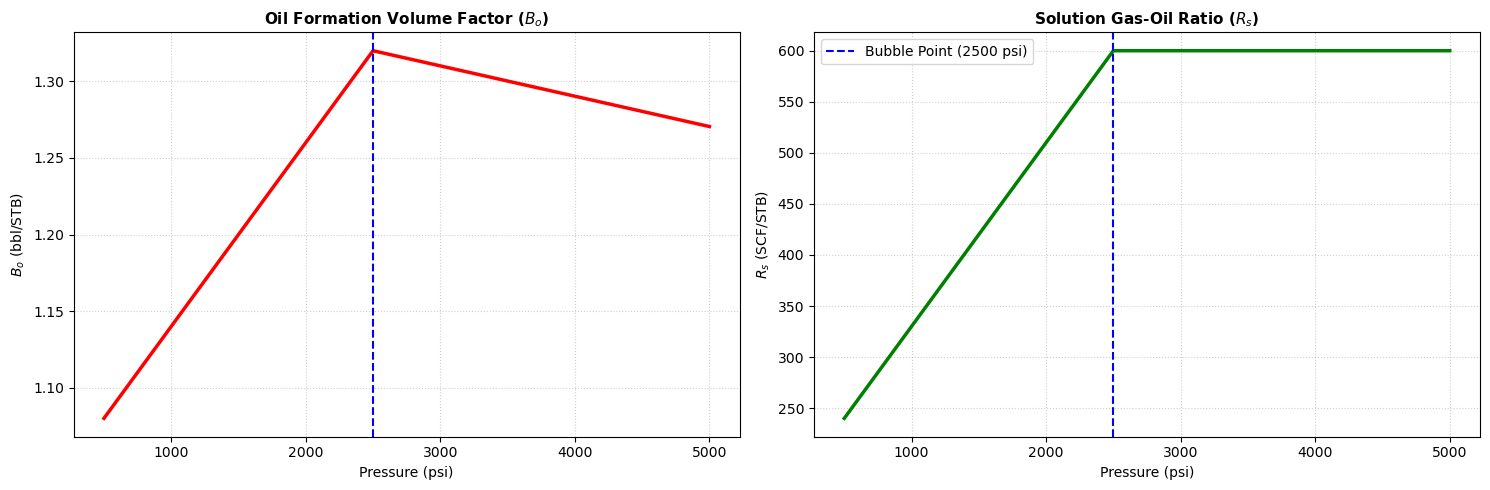

In [4]:
# 1. تعريف القيم الثابتة للغاز المذاب
Rs_max = 600 # كمية الغاز المذاب عند ضغط الفقاعة (SCF/STB)

Rs_results = []

# 2. حساب قيم Rs بناءً على الضغط
for P in pressures:
    if P >= P_b:
        # فوق ضغط الفقاعة: الغاز كله مذاب ولا يتغير
        Rs = Rs_max
    else:
        # تحت ضغط الفقاعة: الغاز يتحرر وتقل قيمته داخل النفط
        Rs = Rs_max - 0.18 * (P_b - P)
    Rs_results.append(Rs)

Rs_results = np.array(Rs_results)

# 3. رسم المنحنيين معاً بشكل متجاور (Subplots)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# الرسمة الأولى: Bo vs Pressure
ax1.plot(pressures, Bo_results, color='red', linewidth=2.5)
ax1.axvline(x=P_b, color='blue', linestyle='--')
ax1.set_title('Oil Formation Volume Factor ($B_o$)', fontsize=11, fontweight='bold')
ax1.set_xlabel('Pressure (psi)')
ax1.set_ylabel('$B_o$ (bbl/STB)')
ax1.grid(True, linestyle=':', alpha=0.6)

# الرسمة الثانية: Rs vs Pressure
ax2.plot(pressures, Rs_results, color='green', linewidth=2.5)
ax2.axvline(x=P_b, color='blue', linestyle='--', label=f'Bubble Point ({P_b} psi)')
ax2.set_title('Solution Gas-Oil Ratio ($R_s$)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Pressure (psi)')
ax2.set_ylabel('$R_s$ (SCF/STB)')
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()